In [ ]:
import pandas as pd
import numpy as np
import os

df_open = pd.read_csv('/content/csi_open.csv')
df_close = pd.read_csv('/content/csi_close.csv')
df_person = pd.read_csv('/content/csi_person.csv')

# Import and remove cols with minimal/no variance
cols = [f'SC_{i}' for i in range(4, 60) if i != 32]
df_temp = pd.concat([df_open[cols], df_close[cols], df_person[cols]])
variances = df_temp.std()
feature_cols = variances[variances > 0.1].index.tolist()

df_open = df_open[feature_cols].copy()
df_close = df_close[feature_cols].copy()
df_person = df_person[feature_cols].copy()
df_open['label'] = 0
df_close['label'] = 1
df_person['label'] = 2
df_combined = pd.concat([df_open, df_close, df_person], axis=0, ignore_index=True)

# Display summary info to verify
print(f'Combined DataFrame shape: {df_combined.shape}')
print(df_combined.head())
print('\nLabel distribution:')
print(df_combined['label'].value_counts())

Combined DataFrame shape: (600, 46)
   SC_4  SC_5  SC_6  SC_7  SC_8  SC_9  SC_10  SC_11  SC_12  SC_13  ...  SC_51  \
0   113    99    99    97    86    86     76     89     89     80  ...    110   
1   196   164   145   128   102    88     67     67     55     55  ...    135   
2   105   105   108   108   108    94    100    100    106    114  ...    106   
3    39    31    24    25    24    35     47     47     62     62  ...    155   
4    63    41    28    18     7     2      3      9     28     48  ...     71   

   SC_52  SC_53  SC_54  SC_55  SC_56  SC_57  SC_58  SC_59  label  
0    129    110    116     99    116    121    121    111      0  
1    145    169    183    199    199    183    223    245      0  
2    100    100    100    111    108    108    105    124      0  
3    133    121    113    126    124    126    113    113      0  
4     97    138    176    219    255    255    255    255      0  

[5 rows x 46 columns]

Label distribution:
label
0    200
1    200
2    20

In [ ]:
def extract_features(df, feature_cols, window_size=5, session_offset=0, calibration_val=None):
    raw_data = df[feature_cols].values.astype(float)
    calibrated_data = raw_data + session_offset
    num_rows = calibrated_data.shape[0]
    all_features = []

    for i in range(num_rows):
        start = max(0, i - window_size + 1)
        window = calibrated_data[start:i+1, :]
        current_frame = calibrated_data[i, :]
        temp_std = np.std(window, axis=0)
        avg_variation = np.mean(temp_std)

        if calibration_val is not None:
            avg_variation = avg_variation / (calibration_val + 1e-8)
        feat = np.concatenate([current_frame, [avg_variation]])
        all_features.append(feat)
    return np.array(all_features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

cal_frames = 20

# Calibration
train_baseline = np.mean(extract_features(df_open.head(cal_frames), feature_cols)[:, -1])

X = extract_features(df_combined, feature_cols, calibration_val=train_baseline)
y = df_combined['label'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f'Training set shape: {X_train.shape}')
print(f'Testing set shape: {X_test.shape}')

Training set shape: (480, 46)
Testing set shape: (120, 46)


In [ ]:
import tensorflow as tf

def build_model(input_dim):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(3, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(0.0005),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_model(X_train.shape[1])
print("Starting model training...")
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=150, batch_size=16, verbose=0,
                    callbacks=[tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)])
model.summary()
print(f"Val Accuracy: {model.evaluate(X_test, y_test, verbose=0)[1]:.4f}")

Starting model training...


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 256)            │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,211 (637.55 KB)

 Trainable params: 54,147 (211.51 KB)

 Non-trainable params: 768 (3.00 KB)

 Optimizer params: 108,296 (423.04 KB)

Val Accuracy: 0.8500


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Confusion Matrix:
[[36  2  2]
 [ 6 34  0]
 [ 1  7 32]]

Classification Report:
              precision    recall  f1-score   support

        open       0.84      0.90      0.87        40
       close       0.79      0.85      0.82        40
      person       0.94      0.80      0.86        40

    accuracy                           0.85       120
   macro avg       0.86      0.85      0.85       120
weighted avg       0.86      0.85      0.85       120



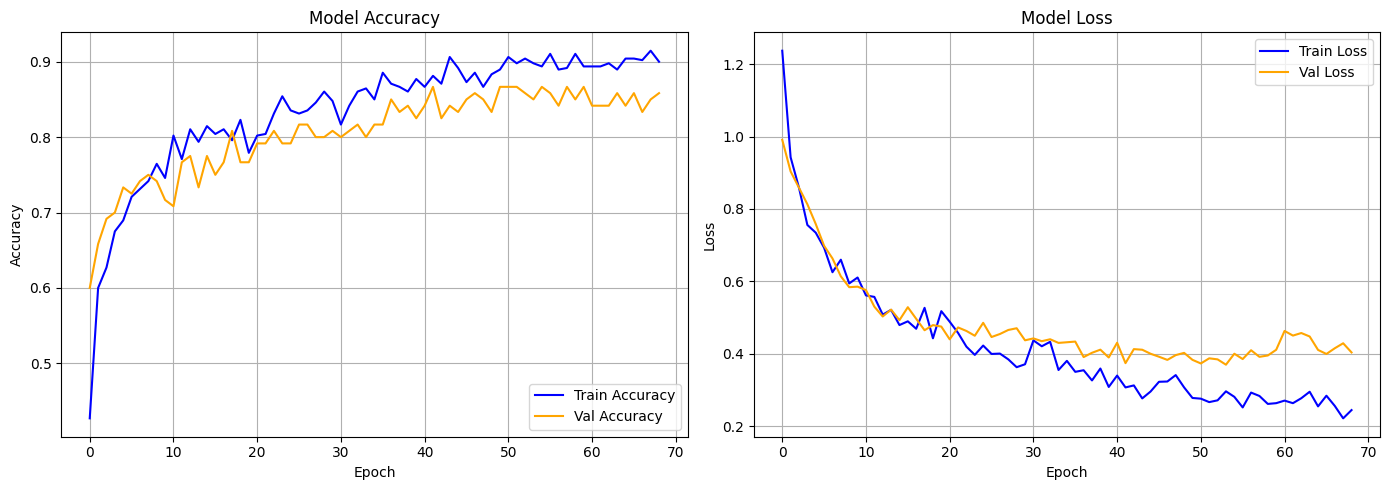

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1. Predict classes for X_test
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Print evaluation metrics
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['open', 'close', 'person']))

# 3. Visualize training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(loc='lower right')
ax1.grid(True)

# Loss Plot
ax2.plot(history.history['loss'], label='Train Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Val Loss', color='orange')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(loc='upper right')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Full Float Model
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

tflite_file_path = '/content/model.tflite'
with open(tflite_file_path, 'wb') as f:
    f.write(tflite_model)

# Verify the file exists
if os.path.exists(tflite_file_path):
    print(f'Success: Model successfully converted and saved to {tflite_file_path}')
    print(f'File size: {os.path.getsize(tflite_file_path)} bytes')
else:
    print('Error: Failed to save the TFLite model.')

Saved artifact at '/tmp/tmpe9badyju'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 55), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  137504352859152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137504352862032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137504352860880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137504352861840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137504352859920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137504037667856: TensorSpec(shape=(), dtype=tf.resource, name=None)
Success: Model successfully converted and saved to /content/model.tflite
File size: 25172 bytes


In [ ]:
# Full Int Model
def export_to_tflite_full_int(model, X_reference, filename='model_full_int.tflite'):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    def representative_data_gen():
        for i in range(100):
            sample = X_reference[i:i+1].astype(np.float32)
            yield [sample]

    converter.representative_dataset = representative_data_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    tflite_model = converter.convert()

    with open(filename, 'wb') as f:
        f.write(tflite_model)

    print(f'Full Integer Model exported to {filename}')
    # Verify the new specs
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    print('Input Details:', interpreter.get_input_details()[0]['dtype'])
    print('Output Details:', interpreter.get_output_details()[0]['dtype'])

export_to_tflite_full_int(model, X_train)

In [ ]:
# Int8 Quantized Model (Float32 IO)
def export_quantized_model(model, filename='model_quantized.tflite'):
    quant_converter = tf.lite.TFLiteConverter.from_keras_model(model)
    quant_converter.optimizations = [tf.lite.Optimize.DEFAULT]
    quant_tflite_model = quant_converter.convert()

    with open(filename, 'wb') as f:
        f.write(quant_tflite_model)

    if os.path.exists(filename):
        print(f'Success: Weight-quantized model saved to {filename}')
        print(f'File size: {os.path.getsize(filename)} bytes')

        interpreter = tf.lite.Interpreter(model_content=quant_tflite_model)
        print('Input Dtype:', interpreter.get_input_details()[0]['dtype'])
        print('Output Dtype:', interpreter.get_output_details()[0]['dtype'])
    else:
        print('Error: Failed to save the quantized TFLite model.')

export_quantized_model(model)

Saved artifact at '/tmp/tmpkylfntl4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 46), dtype=tf.float32, name='keras_tensor_50')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  138994005323088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138994005323472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138994005320784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138994005324816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138994005325008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138994005323856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138994005324240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138994005323280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138994005318864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138994005325968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138994005325776: Ten

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
def run_calibrated_inference(test_csv_path, model, scaler):
    test_df = pd.read_csv(test_csv_path)
    class_map = {0: 'Open', 1: 'Close', 2: 'Person'}

    # Session Calibration
    raw_feats = (test_df, feature_cols, calibration_val=None)
    session_baseline = np.mean(raw_feats[:cal_frames, -1])

    # Signature Alignment: Remove magnitude offset relative to training
    train_mean = 114.8
    offset = train_mean - test_df[feature_cols].values.mean()

    final_feats = extract_features(test_df, feature_cols, session_offset=offset, calibration_val=session_baseline)
    scaled_feats = scaler.transform(final_feats)

    preds = np.argmax(model.predict(scaled_feats, verbose=0), axis=1)
    counts = pd.Series(preds).map(class_map).value_counts()

    print("--- Session Inference Results ---")
    print(f"Detected Session Baseline: {session_baseline:.4f}")
    print(f"Applied Magnitude Offset: {offset:.2f}")
    print(counts)

run_calibrated_inference('/content/test.csv', model, scaler)

--- Session Inference Results ---
Detected Session Baseline: 49.7488
Applied Magnitude Offset: -0.93
Person    144
Close      39
Open       17
Name: count, dtype: int64
